# Hito 1 — Exploratory Data Analysis & Survival Analysis

## Business framing

**The core problem with standard LTV models in travel eSIM:**
Classical LTV frameworks — BG/NBD, Pareto/NBD, and most churn-based approaches — assume that once a customer stops purchasing, there is some probability they have "died" (permanently churned). This is a valid assumption for subscription products where non-renewal is a clear signal.

Travel eSIM breaks this assumption. A travel eSIM customer who last bought a plan 9 months ago has not churned — they are almost certainly waiting for their next trip. Their purchase behaviour is driven by **travel macro-cycles** (annual summer holiday, Christmas trip, etc.), not by random dropout with a constant hazard rate.

**What this notebook establishes:**
1. Who our customers are (archetype distribution and purchase cadence)
2. Empirical proof that dormant ≠ churned (Kaplan-Meier plateau at 12 months)
3. Margin profiles by destination corridor (needed for LTV-pricing bridge in Hito 3)
4. The distribution shape of travel spend (zero-inflated, heavy-tailed — motivates our model choices in Hito 2)

---

In [1]:
import sys
from pathlib import Path

# Make src importable from notebooks/
sys.path.insert(0, str(Path.cwd().parent))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from src.generate_data import main as generate_data
from src.survival import build_survival_frame, kaplan_meier, build_km_by_group

# ── Plotting style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#fafafa",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.4,
    "grid.linestyle": "--",
    "font.family": "sans-serif",
    "font.size": 11,
})

PALETTE = {
    "leisure_once":    "#4C72B0",
    "leisure_repeat":  "#DD8452",
    "digital_nomad":   "#55A868",
    "all":             "#404040",
}
CORRIDOR_PALETTE = {
    "thailand":       "#8172B2",
    "western_europe": "#4C72B0",
    "usa":            "#DD8452",
    "argentina":      "#C44E52",
}

DATA_DIR = Path("../data/raw")
print("Dependencies loaded ✓")

Dependencies loaded ✓


## 1. Generate (or load) synthetic data

In [2]:
# Regenerate if data not present
if not (DATA_DIR / "transactions.parquet").exists():
    print("Data not found — generating …")
    generate_data(output_dir=str(DATA_DIR))
else:
    print("Loading existing data …")

users = pd.read_parquet(DATA_DIR / "users.parquet")
txns  = pd.read_parquet(DATA_DIR / "transactions.parquet")

# Separate purchase events from retention pings
purchases = txns[~txns["is_retention_ping"]].copy()
pings     = txns[txns["is_retention_ping"]].copy()

OBS_END = pd.Timestamp("2024-01-01")

print(f"  Users:        {len(users):,}")
print(f"  Purchases:    {len(purchases):,}")
print(f"  Retention pings: {len(pings):,}")
print(f"  Observation window: {txns['date'].min().date()} → {OBS_END.date()}")

Loading existing data …
  Users:        2,000
  Purchases:    4,486
  Retention pings: 12,714
  Observation window: 2021-01-01 → 2024-01-01


## 2. Customer archetype overview

In [3]:
# Purchase count per user
purchase_counts = (
    purchases.groupby("user_id")
    .size()
    .reset_index(name="n_purchases")
    .merge(users[["user_id", "archetype"]], on="user_id")
)

# Summary by archetype
archetype_summary = (
    purchase_counts.groupby("archetype")["n_purchases"]
    .agg(["count", "mean", "median", "std"])
    .rename(columns={"count": "n_users", "mean": "avg_purchases",
                     "median": "median_purchases", "std": "std_purchases"})
    .round(2)
)

# Revenue per archetype
rev_by_archetype = (
    purchases.merge(users[["user_id", "archetype"]], on="user_id")
    .groupby("archetype")["revenue_eur"]
    .agg(["sum", "mean"])
    .rename(columns={"sum": "total_revenue", "mean": "avg_revenue_per_txn"})
    .round(2)
)

summary = archetype_summary.join(rev_by_archetype)
print(summary.to_string())

                n_users  avg_purchases  median_purchases  std_purchases  total_revenue  avg_revenue_per_txn
archetype                                                                                                  
digital_nomad       105           8.86               9.0           1.95       28976.81                31.16
leisure_once       1381           1.84               2.0           0.79       77229.66                30.38
leisure_repeat      301           3.37               3.0           1.35       30375.70                29.96


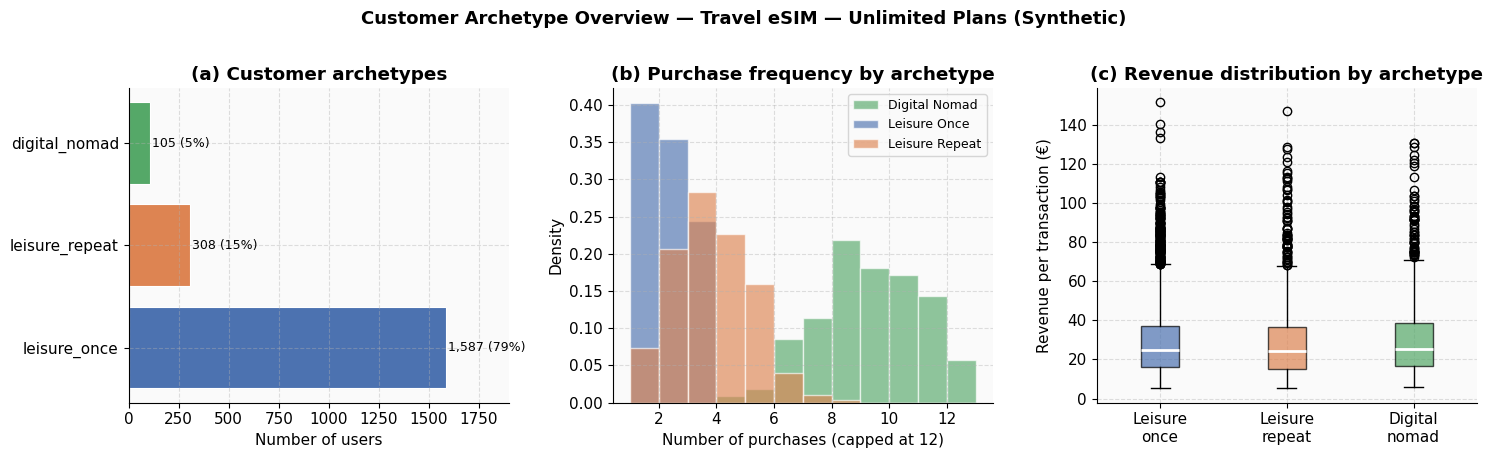

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── (a) Archetype distribution ──────────────────────────────────────────────
ax = axes[0]
counts = users["archetype"].value_counts()
bars = ax.barh(
    counts.index,
    counts.values,
    color=[PALETTE[k] for k in counts.index],
    edgecolor="white", linewidth=0.8,
)
for bar, v in zip(bars, counts.values):
    ax.text(v + 10, bar.get_y() + bar.get_height() / 2,
            f"{v:,} ({v/len(users):.0%})",
            va="center", fontsize=9)
ax.set_xlabel("Number of users")
ax.set_title("(a) Customer archetypes", fontweight="bold")
ax.set_xlim(0, 1900)

# ── (b) Purchase count distribution by archetype ─────────────────────────
ax = axes[1]
for archetype, grp in purchase_counts.groupby("archetype"):
    ax.hist(
        grp["n_purchases"].clip(upper=12),
        bins=range(1, 14),
        alpha=0.65,
        label=archetype.replace("_", " ").title(),
        color=PALETTE[archetype],
        edgecolor="white",
        density=True,
    )
ax.set_xlabel("Number of purchases (capped at 12)")
ax.set_ylabel("Density")
ax.set_title("(b) Purchase frequency by archetype", fontweight="bold")
ax.legend(fontsize=9)

# ── (c) Revenue per transaction by archetype ─────────────────────────────
ax = axes[2]
data = [
    purchases.merge(users[["user_id", "archetype"]], on="user_id")
    .loc[lambda d: d["archetype"] == arch, "revenue_eur"]
    .values
    for arch in ["leisure_once", "leisure_repeat", "digital_nomad"]
]
bp = ax.boxplot(
    data,
    labels=["Leisure\nonce", "Leisure\nrepeat", "Digital\nnomad"],
    patch_artist=True,
    medianprops={"color": "white", "linewidth": 2},
)
for patch, color in zip(bp["boxes"], [PALETTE[k] for k in
                                       ["leisure_once", "leisure_repeat", "digital_nomad"]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel("Revenue per transaction (€)")
ax.set_title("(c) Revenue distribution by archetype", fontweight="bold")

fig.suptitle("Customer Archetype Overview — Travel eSIM — Unlimited Plans (Synthetic)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../data/processed/fig_archetype_overview.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 3. Corridor margin profiles

In [5]:
# Aggregate margin stats by corridor
corridor_stats = (
    purchases.groupby("corridor")
    .agg(
        n_transactions=("revenue_eur", "count"),
        revenue_median=("revenue_eur", "median"),
        cost_median=("cost_eur", "median"),
        margin_median=("margin_eur", "median"),
        margin_mean=("margin_eur", "mean"),
        margin_pct_median=("margin_eur", lambda x:
                           (x / purchases.loc[x.index, "revenue_eur"]).median() * 100),
    )
    .round(2)
    .sort_values("margin_median", ascending=False)
)
print(corridor_stats.to_string())

                n_transactions  revenue_median  cost_median  margin_median  margin_mean  margin_pct_median
corridor                                                                                                  
usa                       1268           27.60        10.42          17.08        20.80              62.91
argentina                  922           34.87        18.78          14.99        18.32              45.79
western_europe            1482           22.50         8.34          14.10        16.86              63.60
thailand                   814           14.46         3.68          10.78        13.00              74.81


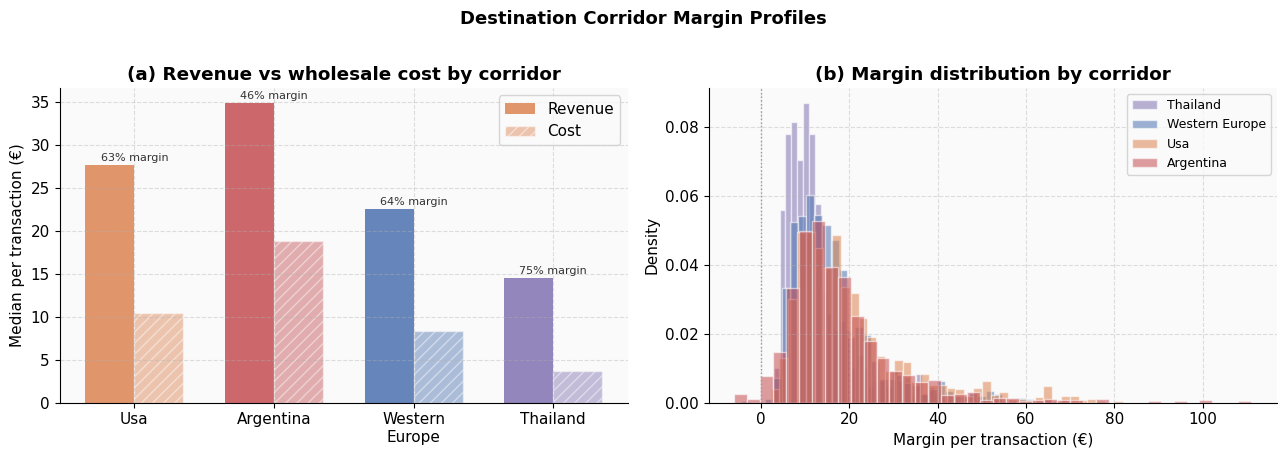

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── (a) Revenue vs Cost by corridor ─────────────────────────────────────
ax = axes[0]
corridors = corridor_stats.index.tolist()
x = np.arange(len(corridors))
width = 0.35
bars1 = ax.bar(x - width/2, corridor_stats["revenue_median"],
               width, label="Revenue", alpha=0.85,
               color=[CORRIDOR_PALETTE[c] for c in corridors])
bars2 = ax.bar(x + width/2, corridor_stats["cost_median"],
               width, label="Cost", alpha=0.45,
               color=[CORRIDOR_PALETTE[c] for c in corridors],
               hatch="///", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels([c.replace("_", "\n").title() for c in corridors])
ax.set_ylabel("Median per transaction (€)")
ax.set_title("(a) Revenue vs wholesale cost by corridor", fontweight="bold")
ax.legend()

# Annotate margin %
for i, corr in enumerate(corridors):
    pct = corridor_stats.loc[corr, "margin_pct_median"]
    ax.text(i, corridor_stats.loc[corr, "revenue_median"] + 0.5,
            f"{pct:.0f}% margin", ha="center", fontsize=8, color="#333")

# ── (b) Margin distribution by corridor ─────────────────────────────────
ax = axes[1]
for corr in ["thailand", "western_europe", "usa", "argentina"]:
    data = purchases[purchases["corridor"] == corr]["margin_eur"]
    ax.hist(
        data,
        bins=40,
        alpha=0.55,
        label=corr.replace("_", " ").title(),
        color=CORRIDOR_PALETTE[corr],
        density=True,
        edgecolor="white",
    )
ax.set_xlabel("Margin per transaction (€)")
ax.set_ylabel("Density")
ax.set_title("(b) Margin distribution by corridor", fontweight="bold")
ax.legend(fontsize=9)

# Note: Argentina has negative margins in the tail (stochastic cost model)
ax.axvline(0, color="#999", linestyle=":", linewidth=1, label="Break-even")

fig.suptitle("Destination Corridor Margin Profiles",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../data/processed/fig_corridor_margins.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 4. Purchase timing: proving the travel macro-cycle

Before fitting any survival model, we need to verify that our synthetic data exhibits the seasonal structure an unlimited-plan travel eSIM provider sees.

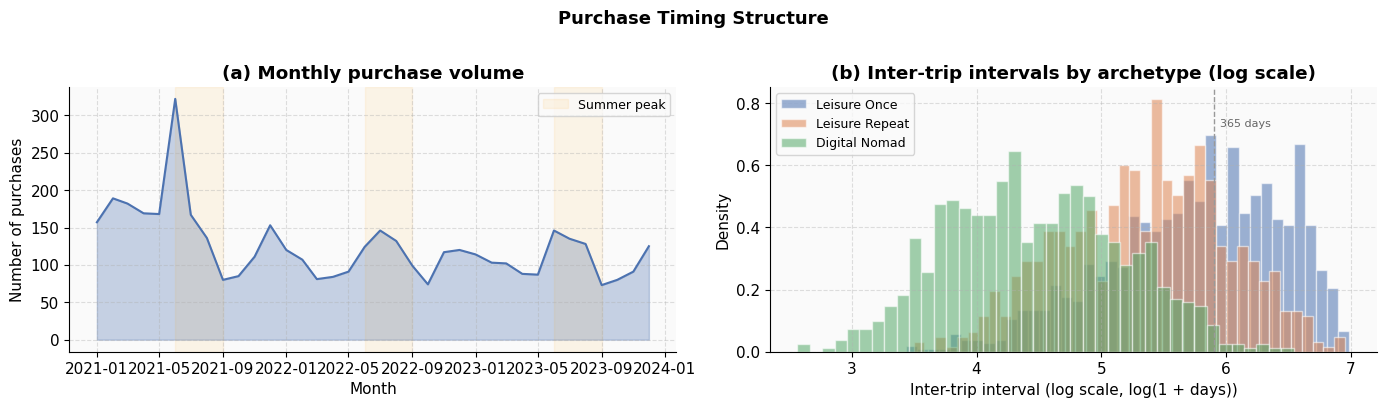

In [7]:
# Monthly purchase volume
purchases["year_month"] = purchases["date"].dt.to_period("M")
monthly = purchases.groupby("year_month").size().reset_index(name="n_purchases")
monthly["date"] = monthly["year_month"].dt.to_timestamp()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── (a) Monthly volume ──────────────────────────────────────────────────
ax = axes[0]
ax.fill_between(monthly["date"], monthly["n_purchases"],
                alpha=0.3, color="#4C72B0")
ax.plot(monthly["date"], monthly["n_purchases"],
        color="#4C72B0", linewidth=1.5)
ax.set_xlabel("Month")
ax.set_ylabel("Number of purchases")
ax.set_title("(a) Monthly purchase volume", fontweight="bold")

# Shade summer peaks
for year in [2021, 2022, 2023]:
    ax.axvspan(pd.Timestamp(f"{year}-06-01"), pd.Timestamp(f"{year}-09-01"),
               alpha=0.08, color="orange", label="Summer peak" if year == 2021 else None)
ax.legend(fontsize=9)

# ── (b) Inter-trip interval distribution (log scale) ────────────────────
ax = axes[1]
survival_df = build_survival_frame(txns, OBS_END, include_retention_pings=False)
survival_with_arch = survival_df.merge(
    users[["user_id", "archetype"]], on="user_id", how="left"
)
# Only events (observed inter-trip intervals)
events = survival_with_arch[survival_with_arch["event"] == 1]

for archetype in ["leisure_once", "leisure_repeat", "digital_nomad"]:
    data = events[events["archetype"] == archetype]["days_to_next"]
    ax.hist(
        np.log1p(data),
        bins=40,
        alpha=0.55,
        label=archetype.replace("_", " ").title(),
        color=PALETTE[archetype],
        density=True,
        edgecolor="white",
    )

# Annotate the ~365-day cluster
ax.axvline(np.log1p(365), color="#999", linestyle="--", linewidth=1)
ax.text(np.log1p(365) + 0.05, ax.get_ylim()[1] * 0.85,
        "365 days", fontsize=8, color="#666")

ax.set_xlabel("Inter-trip interval (log scale, log(1 + days))")
ax.set_ylabel("Density")
ax.set_title("(b) Inter-trip intervals by archetype (log scale)", fontweight="bold")
ax.legend(fontsize=9)

fig.suptitle("Purchase Timing Structure",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../data/processed/fig_purchase_timing.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 5. Kaplan-Meier survival analysis

### Why Kaplan-Meier?

KM is a non-parametric estimator of the survival function S(t) = P(T > t), where T is the time to the next purchase. Crucially:
- It handles **right-censoring** correctly (users who haven't bought again yet are not dropped — they are censored at the observation date)
- It makes **no distributional assumptions**
- The **plateau** in S(t) at large t directly shows that a substantial fraction of users are not lost — they are waiting

**Key prediction:** If dormant ≠ churned, we expect S(t) to stop declining sharply and plateau at ~12 months, reflecting users waiting for their next annual trip.

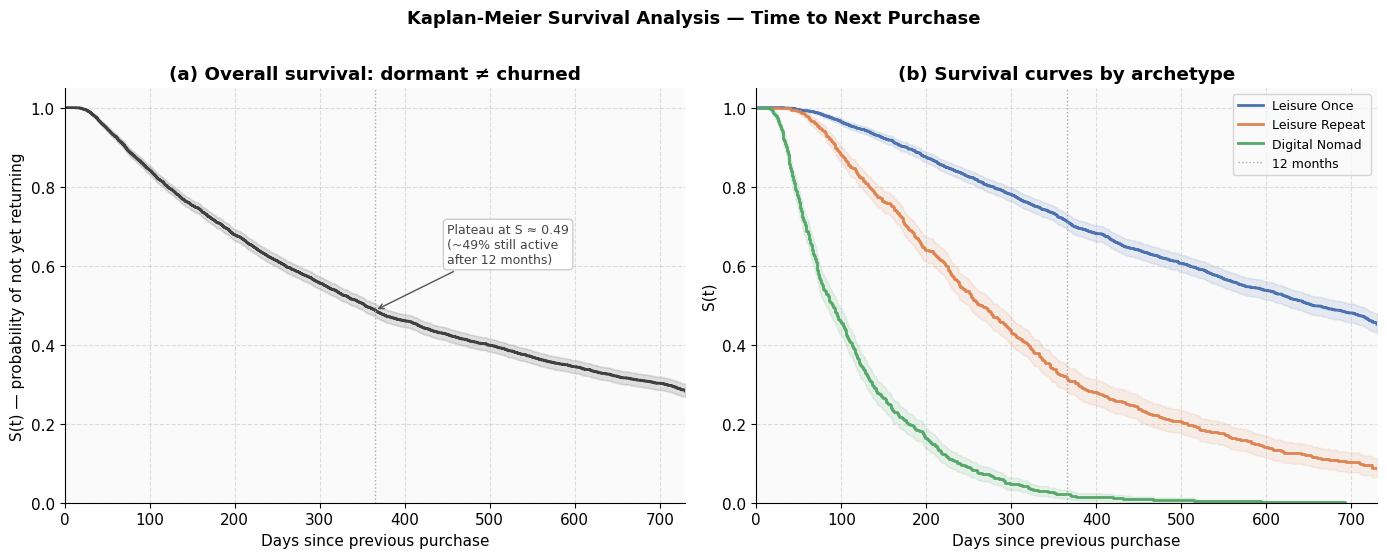

In [8]:
km_results = build_km_by_group(txns, users, OBS_END, group_col="archetype")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ── (a) Overall KM curve ─────────────────────────────────────────────────
ax = axes[0]
km_all = km_results[km_results["label"] == "all"]
km_all = km_all[km_all["time"] <= 730]  # 2-year window

ax.step(km_all["time"], km_all["survival"],
        color=PALETTE["all"], linewidth=2, where="post", label="All users")
ax.fill_between(km_all["time"],
                km_all["lower_ci"], km_all["upper_ci"],
                step="post", alpha=0.15, color=PALETTE["all"])

# Annotate the plateau
plateau_val = km_all[km_all["time"] >= 365]["survival"].iloc[0]
ax.annotate(
    f"Plateau at S ≈ {plateau_val:.2f}\n(~{plateau_val:.0%} still active\nafter 12 months)",
    xy=(365, plateau_val),
    xytext=(450, plateau_val + 0.12),
    arrowprops=dict(arrowstyle="->", color="#555"),
    fontsize=9, color="#444",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#ccc"),
)

ax.axvline(365, color="#aaa", linestyle=":", linewidth=1)
ax.set_xlabel("Days since previous purchase")
ax.set_ylabel("S(t) — probability of not yet returning")
ax.set_title("(a) Overall survival: dormant ≠ churned", fontweight="bold")
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 730)

# ── (b) KM by archetype ─────────────────────────────────────────────────
ax = axes[1]
for archetype in ["leisure_once", "leisure_repeat", "digital_nomad"]:
    grp = km_results[
        (km_results["label"] == archetype) & (km_results["time"] <= 730)
    ]
    if grp.empty:
        continue
    label = archetype.replace("_", " ").title()
    ax.step(grp["time"], grp["survival"],
            color=PALETTE[archetype], linewidth=2,
            where="post", label=label)
    ax.fill_between(grp["time"],
                    grp["lower_ci"], grp["upper_ci"],
                    step="post", alpha=0.12, color=PALETTE[archetype])

ax.axvline(365, color="#aaa", linestyle=":", linewidth=1, label="12 months")
ax.set_xlabel("Days since previous purchase")
ax.set_ylabel("S(t)")
ax.set_title("(b) Survival curves by archetype", fontweight="bold")
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 730)
ax.legend(fontsize=9)

fig.suptitle(
    "Kaplan-Meier Survival Analysis — Time to Next Purchase",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("../data/processed/fig_kaplan_meier.png",
            dpi=150, bbox_inches="tight")
plt.show()

### Interpreting the survival curves

The curves confirm two key hypotheses:

1. **The 12-month plateau is real.** S(t) stops declining sharply around day 365 for all archetypes. This means a substantial fraction of users remain in a "pending trip" state well past the point where standard models would write them off as churned.

2. **Archetypes have meaningfully different curves.** Digital nomads return quickly (median time to next purchase < 90 days), while leisure-once users have a slow, flattening curve. This is what will allow our LightGBM model in Hito 2 to discriminate LTV by segment — and what justifies different discount strategies in Hito 3.

## 6. Revenue distribution shape

Understanding the spend distribution is critical for model selection. Standard linear regression assumes Gaussian errors. The actual distribution of user-level total spend in travel eSIM is:

Zero-purchase users: 213 (10.7% of cohort)


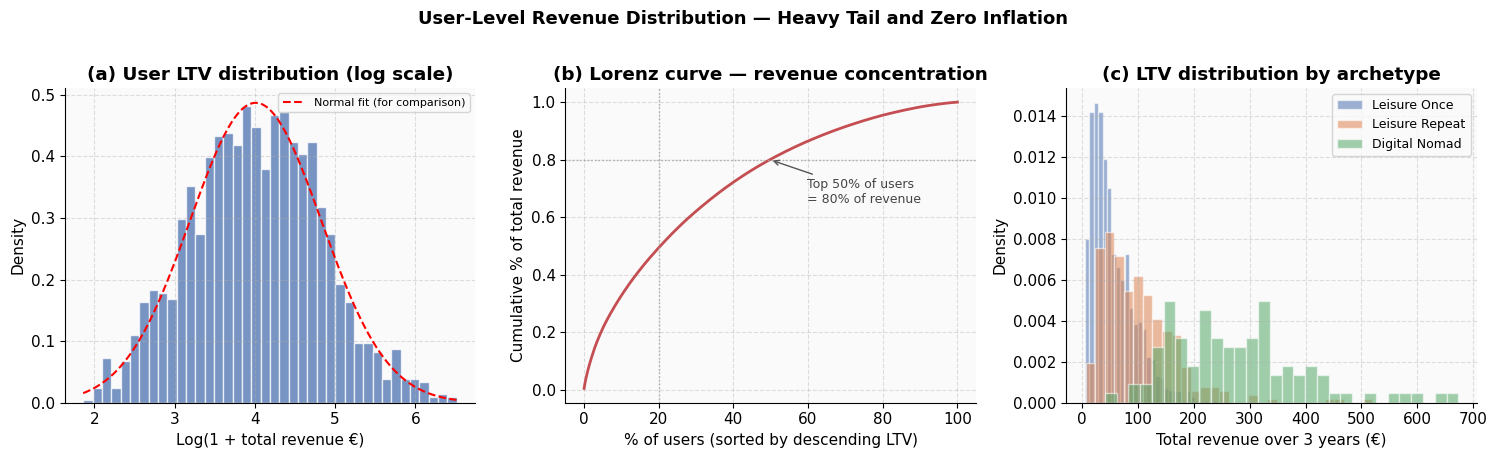

In [9]:
# User-level LTV proxy (total revenue over 3 years)
user_ltv = (
    purchases.groupby("user_id")
    .agg(
        total_revenue=("revenue_eur", "sum"),
        total_margin=("margin_eur", "sum"),
        n_purchases=("revenue_eur", "count"),
    )
    .reset_index()
    .merge(users[["user_id", "archetype"]], on="user_id", how="left")
)

# Users with zero purchases (signed up, never bought in 3 years)
zero_purchase_users = len(users) - len(user_ltv)
print(f"Zero-purchase users: {zero_purchase_users} "
      f"({zero_purchase_users/len(users):.1%} of cohort)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── (a) Total revenue distribution (log scale) ──────────────────────────
ax = axes[0]
ax.hist(
    np.log1p(user_ltv["total_revenue"]),
    bins=40,
    color="#4C72B0",
    alpha=0.75,
    edgecolor="white",
    density=True,
)
ax.set_xlabel("Log(1 + total revenue €)")
ax.set_ylabel("Density")
ax.set_title("(a) User LTV distribution (log scale)", fontweight="bold")

# Overlay a normal for comparison
log_rev = np.log1p(user_ltv["total_revenue"])
mu, sigma = log_rev.mean(), log_rev.std()
x = np.linspace(log_rev.min(), log_rev.max(), 200)
from scipy.stats import norm
ax.plot(x, norm.pdf(x, mu, sigma), "r--", linewidth=1.5,
        label="Normal fit (for comparison)")
ax.legend(fontsize=8)

# ── (b) Pareto-like tail ─────────────────────────────────────────────────
ax = axes[1]
sorted_rev = user_ltv["total_revenue"].sort_values(ascending=False).reset_index(drop=True)
cum_rev = sorted_rev.cumsum() / sorted_rev.sum()
pct_users = (sorted_rev.index + 1) / len(sorted_rev) * 100
ax.plot(pct_users, cum_rev.values, color="#C44E52", linewidth=2)
ax.axhline(0.8, color="#aaa", linestyle=":", linewidth=1)
ax.axvline(20, color="#aaa", linestyle=":", linewidth=1)
# Find where top X% generates 80% of revenue
top_pct = pct_users.values[cum_rev.values >= 0.80][0] if (cum_rev.values >= 0.80).any() else None
if top_pct:
    ax.annotate(f"Top {top_pct:.0f}% of users\n= 80% of revenue",
                xy=(top_pct, 0.80),
                xytext=(top_pct + 10, 0.65),
                arrowprops=dict(arrowstyle="->", color="#555"),
                fontsize=9, color="#444")
ax.set_xlabel("% of users (sorted by descending LTV)")
ax.set_ylabel("Cumulative % of total revenue")
ax.set_title("(b) Lorenz curve — revenue concentration", fontweight="bold")

# ── (c) LTV by archetype ─────────────────────────────────────────────────
ax = axes[2]
for archetype in ["leisure_once", "leisure_repeat", "digital_nomad"]:
    data = user_ltv[user_ltv["archetype"] == archetype]["total_revenue"]
    ax.hist(
        data,
        bins=30,
        alpha=0.55,
        label=archetype.replace("_", " ").title(),
        color=PALETTE[archetype],
        density=True,
        edgecolor="white",
    )
ax.set_xlabel("Total revenue over 3 years (€)")
ax.set_ylabel("Density")
ax.set_title("(c) LTV distribution by archetype", fontweight="bold")
ax.legend(fontsize=9)

fig.suptitle(
    "User-Level Revenue Distribution — Heavy Tail and Zero Inflation",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("../data/processed/fig_ltv_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 7. Retention ping signal

The free 1 GB/month after plan expiry is The provider's key retention mechanism — it keeps the eSIM on the device and signals which dormant users are still engaged.

In [10]:
# Compare reactivation rates: users with vs without retention pings
users_with_pings = pings["user_id"].unique()
users_with_subsequent_purchase = (
    purchases.sort_values("date")
    .groupby("user_id")["date"]
    .apply(lambda d: len(d) > 1)
)

ping_df = pd.DataFrame({
    "user_id": users["user_id"],
    "has_ping": users["user_id"].isin(users_with_pings),
    "has_repeat_purchase": users["user_id"].isin(
        users_with_subsequent_purchase[users_with_subsequent_purchase].index
    ),
})

repeat_rate = ping_df.groupby("has_ping")["has_repeat_purchase"].mean()
print("Repeat purchase rate:")
print(f"  Users with retention pings:    {repeat_rate.get(True, 0):.1%}")
print(f"  Users without retention pings: {repeat_rate.get(False, 0):.1%}")
print("\nNote: retention ping is a feature for Hito 2 models.")

Repeat purchase rate:
  Users with retention pings:    68.3%
  Users without retention pings: 0.0%

Note: retention ping is a feature for Hito 2 models.


---

## Key takeaways

1. **Dormant ≠ churned.** The Kaplan-Meier curves show a clear plateau at ~12 months for all archetypes. A user who has not bought in 9 months is likely waiting for their next trip, not lost. This invalidates standard churn-based LTV approaches and motivates the BG/NBD framework and LightGBM survival features we build in Hito 2.

2. **Three distinct archetypes drive very different LTV profiles.** Digital nomads (5% of users) punch above their weight in revenue concentration. The Lorenz curve confirms the typical travel Pareto: a small fraction of high-frequency travellers generate a disproportionate share of total revenue.

3. **Margin is stochastic and corridor-dependent.** Argentina's expensive wholesale creates meaningful margin risk (negative-margin tail). Thailand generates high-volume, low-margin transactions. The pricing bridge in Hito 3 will need to account for corridor-level expected margin, not just revenue.

4. **The spend distribution is lognormal and zero-inflated.** A standard OLS on total revenue would be invalid. Hito 2 will use the Gamma-Gamma model (lognormal spend assumption) as the BG/NBD spend component, and LightGBM will handle the zero-inflation implicitly.

5. **Retention pings are a predictive feature.** Users who generate retention activity have meaningfully higher repeat purchase rates — this signal goes into the feature matrix in Hito 2.

**Next: Hito 2** fits two LTV models (BG/NBD + Gamma-Gamma and LightGBM with RFM + survival features) and evaluates them against a held-out test period.